Modified TPC_RP Algorithm (CIFAR-10)
Task 3: Algorithm Modification: Dynamic Neighbor Scaling (DNS)

Modification: Replace the fixed K=20 in the typicality
calculation with K = max(2, floor(sqrt(cluster_size))),
adapting dynamically to each cluster.


---
## 1. Setup: Imports


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision.models import resnet18

import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import random

#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
# No seeds — fully non-deterministic as required
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 2. Load CIFAR-10 Dataset


In [ ]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Training set size: 50000
Test set size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


---
## 3. Load Pre-trained SimCLR Features

Load the L2-normalized 512-dim features


In [ ]:
# Load pre-extracted L2-normalized train features
features = np.load('simclr_features_500epochs.npy')
print(f"Loaded train features: {features.shape}")

train_labels = np.array(train_dataset.targets)
test_labels = np.array(test_dataset.targets)

Loaded train features: (50000, 512)


---
## 4. SimCLR Model + Extract Test Features (for Framework ii)

Load the trained SimCLR model to extract test features.



In [ ]:
class SimCLRModel(nn.Module):
    def __init__(self, feature_dim=128):
        super(SimCLRModel, self).__init__()
        backbone = resnet18(weights=None)
        # Critical for CIFAR-10 32x32 images (SimCLR paper Appendix B.9)

        self.encoder = nn.Sequential(*list(backbone.children())[:-1])
        self.projection_head = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, feature_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        features = features.squeeze()
        projections = self.projection_head(features)
        return features, projections

# Load trained SimCLR model
model_simclr = SimCLRModel(feature_dim=128).to(device)
model_simclr.load_state_dict(torch.load(
    'simclr_model_500epochs.pth',
    map_location=device))
model_simclr.eval()
print("SimCLR model loaded!")

# Extract L2-normalized test features
@torch.no_grad()
def extract_test_features(model, device, batch_size=256):
    test_feature_dataset = datasets.CIFAR10(
        root='./data', train=False, download=False, transform=basic_transform)
    loader = DataLoader(test_feature_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    model.eval()
    all_features = []
    for images, _ in loader:
        images = images.to(device)
        feats, _ = model(images)
        feats = F.normalize(feats, dim=1)
        all_features.append(feats.cpu().numpy())
    return np.concatenate(all_features, axis=0)

print("Extracting test features...")
test_features = extract_test_features(model_simclr, device)
print(f"Test features shape: {test_features.shape}")

SimCLR model loaded!
Extracting test features...
Test features shape: (10000, 512)


---
## 5. Typicality Score Function

Equation 4 from Hacohen et al. (2022). Same for both original and DNS


In [ ]:
def compute_typicality(features, k_neighbors=20):
    """
    Computes Typicality score for a set of features.
    Equation 4: Typicality(x) = (1/K * sum ||x - x_i||_2)^-1

    Args:
        features (np.ndarray): L2-normalized features (N, D)
        k_neighbors (int): Number of nearest neighbors.

    Returns:
        np.ndarray: Typicality scores for each point.
    """
    n_samples = len(features)

    # Adjust K if cluster size is smaller than k_neighbors (Appendix F.1)
    k = min(k_neighbors, n_samples - 1)

    # Drop clusters too small to be reliable — minimum 5 samples (Appendix F.1)
    if n_samples < 5:
        return np.zeros(n_samples)

    # NearestNeighbors with Euclidean distance
    # Query k+1 because first neighbour is always the point itself (dist=0)
    knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
    knn.fit(features)
    distances, _ = knn.kneighbors(features)

    # Average distance to K nearest neighbours excluding self
    avg_dist = np.mean(distances[:, 1:], axis=1)

    # Typicality = inverse of average distance, epsilon avoids division by zero
    typicality = 1.0 / (avg_dist + 1e-10)
    return typicality

print("Typicality function ready")

Typicality function ready


---
## 6. DNS Modified Selection Function

**Modification:** K = max(2, floor(sqrt(cluster_size))) instead of fixed K=20.
Everything else is identical to the original TPC_RP (Appendix F.1).


In [ ]:
def typicality_clustering_select_dns(features, budget, labeled_indices=None, max_clusters=500):
    """
    Modified TPC_RP with Dynamic Neighbor Scaling (DNS).
    All steps identical to Appendix F.1 except K computation:
    - Original: k = min(20, cluster_size - 1)
    - DNS:      k = max(2, floor(sqrt(cluster_size)))
    """
    if labeled_indices is None:
        labeled_indices = []

    labeled_set = set(labeled_indices)
    n_labeled = len(labeled_indices)

    # K = min(|L_{i-1}| + B, max_clusters) — Appendix F.1
    n_clusters = min(n_labeled + budget, max_clusters)

    print(f"  Running K-Means with {n_clusters} clusters...")

    # KMeans if K<=50, MiniBatchKMeans if K>50 — Appendix F.1
    # No random_state — fully non-deterministic
    if n_clusters <= 50:
        kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    else:
        kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=1024)

    cluster_assignments = kmeans.fit_predict(features)

    # Count labeled points per cluster
    cluster_label_counts = {}
    for idx in labeled_indices:
        c = cluster_assignments[idx]
        cluster_label_counts[c] = cluster_label_counts.get(c, 0) + 1

    # Build cluster index mapping
    cluster_to_indices = {}
    for idx in range(len(features)):
        c = cluster_assignments[idx]
        if c not in cluster_to_indices:
            cluster_to_indices[c] = []
        cluster_to_indices[c].append(idx)

    selected = []

    for _ in range(budget):
        # Select largest cluster with fewest labeled points — Appendix F.1
        best_cluster = None
        best_fewest_labels = float('inf')
        best_cluster_size = -1

        for c, indices in cluster_to_indices.items():
            # Drop clusters with fewer than 5 samples — Appendix F.1
            if len(indices) <= 5:
                continue
            n_labeled_in_cluster = cluster_label_counts.get(c, 0)
            if (n_labeled_in_cluster < best_fewest_labels or
                (n_labeled_in_cluster == best_fewest_labels and
                 len(indices) > best_cluster_size)):
                best_cluster = c
                best_fewest_labels = n_labeled_in_cluster
                best_cluster_size = len(indices)

        if best_cluster is None:
            break

        cluster_indices = cluster_to_indices[best_cluster]
        cluster_features = features[cluster_indices]

        # DNS: K = max(2, floor(sqrt(cluster_size)))
        # Original was: k = min(20, cluster_size - 1)
        k = max(2, min(int(np.sqrt(len(cluster_indices))), len(cluster_indices) - 1))

        # Compute typicality within this cluster only (local, not global)
        cluster_typicality = compute_typicality(cluster_features, k_neighbors=k)

        # Select most typical unlabeled point
        sorted_by_typicality = np.argsort(-cluster_typicality)
        for rank in sorted_by_typicality:
            idx = cluster_indices[rank]
            if idx not in labeled_set and idx not in selected:
                selected.append(idx)
                break

        cluster_label_counts[best_cluster] = cluster_label_counts.get(best_cluster, 0) + 1

    return selected

print("DNS selection function ready")

DNS selection function ready


---
## 7. Framework (i): Fully Supervised Classifier

Paper settings (Appendix F.2.1):


In [ ]:
def train_classifier(labeled_indices, train_dataset, test_dataset, device,
                     num_epochs=100, lr=0.025, batch_size=64):
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    train_data_augmented = datasets.CIFAR10(
        root='./data', train=True, download=False, transform=train_transform)
    labeled_subset = Subset(train_data_augmented, labeled_indices)
    actual_batch_size = min(batch_size, len(labeled_indices))
    train_loader = DataLoader(labeled_subset, batch_size=actual_batch_size,
                              shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

    # Fresh ResNet18 each round (re-initialize weights)
    model = resnet18(weights=None, num_classes=10).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(num_epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100.0 * correct / total

print("Framework (i) classifier ready")

Framework (i) classifier ready


---
## 8. Framework (ii): Linear Classifier on SimCLR Embeddings

Paper settings (Appendix F.2.2):



In [ ]:
def train_linear_classifier(labeled_indices, train_features, train_labels,
                            test_features, test_labels, device,
                            num_epochs=200, lr=2.5, batch_size=64):
    """
    Framework (ii): Single linear layer on SimCLR embeddings.
    Appendix F.2.2: lr=2.5, epochs=200, SGD Nesterov, weight_decay=1e-4
    """
    feature_dim = train_features.shape[1]
    num_classes = len(np.unique(train_labels))

    X_train = torch.tensor(train_features[labeled_indices], dtype=torch.float32)
    y_train = torch.tensor(train_labels[labeled_indices], dtype=torch.long)
    X_test = torch.tensor(test_features, dtype=torch.float32)
    y_test = torch.tensor(test_labels, dtype=torch.long)

    train_data = TensorDataset(X_train, y_train)
    actual_batch_size = min(batch_size, len(labeled_indices))
    train_loader = DataLoader(train_data, batch_size=actual_batch_size, shuffle=True)

    linear_model = nn.Linear(feature_dim, num_classes).to(device)

    optimizer = optim.SGD(linear_model.parameters(), lr=lr,
                          momentum=0.9, nesterov=True, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    linear_model.train()
    for epoch in range(num_epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = linear_model(X_batch)
            loss = criterion(outputs, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()

    linear_model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        test_data = TensorDataset(X_test.to(device), y_test.to(device))
        test_loader = DataLoader(test_data, batch_size=256, shuffle=False)
        for X_batch, y_batch in test_loader:
            outputs = linear_model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return 100.0 * correct / total

print("Framework (ii) linear classifier ready")

Framework (ii) linear classifier ready


---
## 9. Run DNS — Framework (i): Fully Supervised


In [ ]:
BUDGET_PER_ROUND = 10
NUM_ROUNDS = 5
NUM_REPETITIONS = 10

dns_fw1_all = []

for rep in range(NUM_REPETITIONS):
    print(f"\nDNS Framework(i) — Rep {rep+1}/{NUM_REPETITIONS}")
    labeled_indices = []
    round_accs = []

    for round_num in range(NUM_ROUNDS):
        new_indices = typicality_clustering_select_dns(
            features=features,
            budget=BUDGET_PER_ROUND,
            labeled_indices=labeled_indices,
            max_clusters=500
        )
        labeled_indices.extend(new_indices)
        acc = train_classifier(labeled_indices, train_dataset, test_dataset, device)
        round_accs.append(acc)
        print(f"  Round {round_num+1}: Budget={len(labeled_indices)}, Acc={acc:.2f}%")

    dns_fw1_all.append(round_accs)

dns_fw1_all = np.array(dns_fw1_all)
dns_fw1_mean = dns_fw1_all.mean(axis=0)
dns_fw1_std = dns_fw1_all.std(axis=0)

print(f"\nDNS Framework (i) Results:")
for i in range(NUM_ROUNDS):
    b = (i+1) * BUDGET_PER_ROUND
    print(f"Budget {b:4d}: {dns_fw1_mean[i]:.2f}% +/- {dns_fw1_std[i]:.2f}%")


DNS Framework(i) — Rep 1/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Acc=17.17%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Acc=19.67%
  Running K-Means with 30 clusters...
  Round 3: Budget=30, Acc=21.00%
  Running K-Means with 40 clusters...
  Round 4: Budget=40, Acc=22.54%
  Running K-Means with 50 clusters...
  Round 5: Budget=50, Acc=24.94%

DNS Framework(i) — Rep 2/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Acc=16.91%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Acc=20.66%
  Running K-Means with 30 clusters...
  Round 3: Budget=30, Acc=22.68%
  Running K-Means with 40 clusters...
  Round 4: Budget=40, Acc=23.69%
  Running K-Means with 50 clusters...
  Round 5: Budget=50, Acc=24.31%

DNS Framework(i) — Rep 3/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Acc=16.73%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Acc=20.30%
  Running K-Means with 30 clusters...
  Round 3: Budget=30, A

---
## 10. Run DNS — Framework (ii): Linear Classifier on SimCLR Embeddings


In [ ]:
dns_fw2_all = []

for rep in range(NUM_REPETITIONS):
    print(f"\nDNS Framework(ii) — Rep {rep+1}/{NUM_REPETITIONS}")
    labeled_indices = []
    round_accs = []

    for round_num in range(NUM_ROUNDS):
        new_indices = typicality_clustering_select_dns(
            features=features,
            budget=BUDGET_PER_ROUND,
            labeled_indices=labeled_indices,
            max_clusters=500
        )
        labeled_indices.extend(new_indices)

        acc = train_linear_classifier(
            labeled_indices=labeled_indices,
            train_features=features,
            train_labels=train_labels,
            test_features=test_features,
            test_labels=test_labels,
            device=device,
            num_epochs=200,
            lr=2.5
        )
        round_accs.append(acc)
        print(f"  Round {round_num+1}: Budget={len(labeled_indices)}, Acc={acc:.2f}%")

    dns_fw2_all.append(round_accs)

dns_fw2_all = np.array(dns_fw2_all)
dns_fw2_mean = dns_fw2_all.mean(axis=0)
dns_fw2_std = dns_fw2_all.std(axis=0)

print(f"\nDNS Framework (ii) Results:")
for i in range(NUM_ROUNDS):
    b = (i+1) * BUDGET_PER_ROUND
    print(f"Budget {b:4d}: {dns_fw2_mean[i]:.2f}% +/- {dns_fw2_std[i]:.2f}%")


DNS Framework(ii) — Rep 1/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Acc=54.66%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Acc=65.41%
  Running K-Means with 30 clusters...
  Round 3: Budget=30, Acc=67.69%
  Running K-Means with 40 clusters...
  Round 4: Budget=40, Acc=69.92%
  Running K-Means with 50 clusters...
  Round 5: Budget=50, Acc=70.36%

DNS Framework(ii) — Rep 2/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Acc=54.77%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Acc=65.48%
  Running K-Means with 30 clusters...
  Round 3: Budget=30, Acc=67.49%
  Running K-Means with 40 clusters...
  Round 4: Budget=40, Acc=68.24%
  Running K-Means with 50 clusters...
  Round 5: Budget=50, Acc=69.32%

DNS Framework(ii) — Rep 3/10
  Running K-Means with 10 clusters...
  Round 1: Budget=10, Acc=54.64%
  Running K-Means with 20 clusters...
  Round 2: Budget=20, Acc=64.86%
  Running K-Means with 30 clusters...
  Round 3: Budget=30

---
## 11. Plot Results — Framework (i): DNS vs Original vs Random


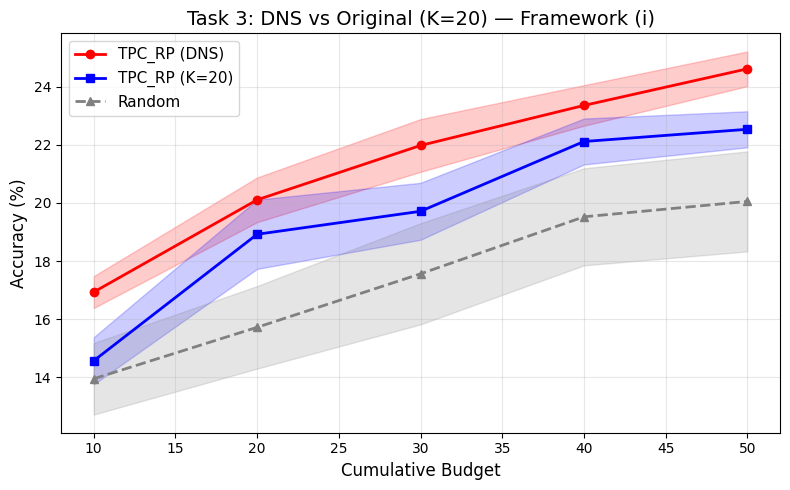

In [ ]:
# Original TPC_RP results from main notebook (Framework i)
orig_fw1_mean = np.array([14.57, 18.92, 19.71, 22.11, 22.53])
orig_fw1_std  = np.array([0.81,  1.19,  0.98,  0.79,  0.62])
rand_fw1_mean = np.array([13.95, 15.72, 17.56, 19.52, 20.05])
rand_fw1_std  = np.array([1.23,  1.42,  1.74,  1.67,  1.72])

budgets = [10, 20, 30, 40, 50]

plt.figure(figsize=(8, 5))
plt.plot(budgets, dns_fw1_mean, 'o-', label='TPC_RP (DNS)', color='red', linewidth=2)
plt.fill_between(budgets, dns_fw1_mean - dns_fw1_std,
                 dns_fw1_mean + dns_fw1_std, alpha=0.2, color='red')
plt.plot(budgets, orig_fw1_mean, 's-', label='TPC_RP (K=20)', color='blue', linewidth=2)
plt.fill_between(budgets, orig_fw1_mean - orig_fw1_std,
                 orig_fw1_mean + orig_fw1_std, alpha=0.2, color='blue')
plt.plot(budgets, rand_fw1_mean, '^--', label='Random', color='gray', linewidth=2)
plt.fill_between(budgets, rand_fw1_mean - rand_fw1_std,
                 rand_fw1_mean + rand_fw1_std, alpha=0.2, color='gray')
plt.xlabel('Cumulative Budget', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Task 3: DNS vs Original (K=20) — Framework (i)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task3_dns_framework_i.png', dpi=150)
plt.show()

---
## 12. Plot Results — Framework (ii): DNS vs Original vs Random


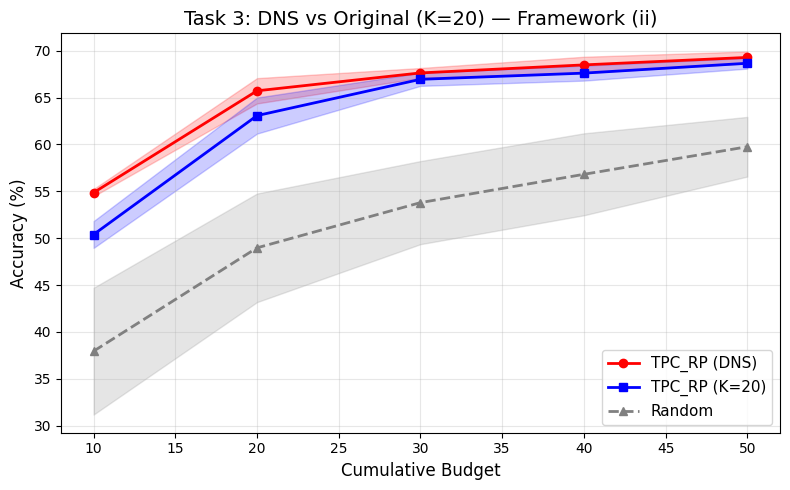

In [ ]:
# Original TPC_RP results from main notebook (Framework ii)
orig_fw2_mean = np.array([50.39, 63.07, 66.94, 67.60, 68.65])
orig_fw2_std  = np.array([1.43,  1.92,  0.70,  0.80,  0.57])
rand_fw2_mean = np.array([37.95, 48.97, 53.79, 56.81, 59.75])
rand_fw2_std  = np.array([6.76,  5.79,  4.43,  4.37,  3.18])

budgets = [10, 20, 30, 40, 50]

plt.figure(figsize=(8, 5))
plt.plot(budgets, dns_fw2_mean, 'o-', label='TPC_RP (DNS)', color='red', linewidth=2)
plt.fill_between(budgets, dns_fw2_mean - dns_fw2_std,
                 dns_fw2_mean + dns_fw2_std, alpha=0.2, color='red')
plt.plot(budgets, orig_fw2_mean, 's-', label='TPC_RP (K=20)', color='blue', linewidth=2)
plt.fill_between(budgets, orig_fw2_mean - orig_fw2_std,
                 orig_fw2_mean + orig_fw2_std, alpha=0.2, color='blue')
plt.plot(budgets, rand_fw2_mean, '^--', label='Random', color='gray', linewidth=2)
plt.fill_between(budgets, rand_fw2_mean - rand_fw2_std,
                 rand_fw2_mean + rand_fw2_std, alpha=0.2, color='gray')
plt.xlabel('Cumulative Budget', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Task 3: DNS vs Original (K=20) — Framework (ii)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task3_dns_framework_ii.png', dpi=150)
plt.show()

---
## 13. Results Summary Tables


In [ ]:
print("=" * 70)
print("Framework (i) — Fully Supervised")
print(f"{'Budget':<10} {'DNS (sqrt K)':<25} {'Original (K=20)':<25}")
print("=" * 70)
for i in range(NUM_ROUNDS):
    b = (i+1) * BUDGET_PER_ROUND
    print(f"{b:<10} "
          f"{dns_fw1_mean[i]:.2f}% ± {dns_fw1_std[i]:.2f}%{'':<10}"
          f"{orig_fw1_mean[i]:.2f}% ± {orig_fw1_std[i]:.2f}%")
print("=" * 70)

print()

print("=" * 70)
print("Framework (ii) — Linear Classifier on SimCLR Embeddings")
print(f"{'Budget':<10} {'DNS (sqrt K)':<25} {'Original (K=20)':<25}")
print("=" * 70)
for i in range(NUM_ROUNDS):
    b = (i+1) * BUDGET_PER_ROUND
    print(f"{b:<10} "
          f"{dns_fw2_mean[i]:.2f}% ± {dns_fw2_std[i]:.2f}%{'':<10}"
          f"{orig_fw2_mean[i]:.2f}% ± {orig_fw2_std[i]:.2f}%")
print("=" * 70)

Framework (i) — Fully Supervised
Budget     DNS (sqrt K)              Original (K=20)          
10         16.93% ± 0.55%          14.57% ± 0.81%
20         20.10% ± 0.77%          18.92% ± 1.19%
30         21.97% ± 0.91%          19.71% ± 0.98%
40         23.35% ± 0.70%          22.11% ± 0.79%
50         24.61% ± 0.60%          22.53% ± 0.62%

Framework (ii) — Linear Classifier on SimCLR Embeddings
Budget     DNS (sqrt K)              Original (K=20)          
10         54.85% ± 0.38%          50.39% ± 1.43%
20         65.71% ± 1.35%          63.07% ± 1.92%
30         67.62% ± 0.52%          66.94% ± 0.70%
40         68.48% ± 0.87%          67.60% ± 0.80%
50         69.27% ± 0.63%          68.65% ± 0.57%


---
## GitHub Repository

🔗 `https://github.com/Taliahashem/CIFAR10-CW2`
